**Script to check basic features of UKESM G6solar precip field.**

Few things to check first:

Plotting global mean surface temperature (GMST). Meaning, if the Global mean surface temperature between G6 and SSP245 is 0, then it would mean that G6 has successfully cooled the world from SSP585 to SSP245.

Also, need to plot G6solar and G6sulfur to see if it is OK to use G6solar. Maybe plot the zonal mean cross-section also.

In [1]:
import xarray as xr
from pathlib import Path
import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
%store -r T_ens
%store -r P_ens


In [3]:
T_ens

{'HIST': array([277.21075, 277.20694, 277.29727, 277.2723 , 277.28122, 277.20523,
        277.2872 , 277.3124 , 277.20856, 277.44586, 277.3991 , 277.34622,
        277.19217, 277.27448, 277.32208, 277.24927, 277.3309 , 277.3022 ,
        277.25912, 277.21222, 277.2467 , 277.38007, 277.28943, 277.32828,
        277.2345 , 277.2233 , 277.2026 , 277.3049 , 277.42316, 277.3255 ,
        277.2364 , 277.30478, 277.2474 , 277.22885, 277.0327 , 277.005  ,
        277.07684, 277.11166, 277.12262, 277.0963 , 277.20114, 277.13007,
        277.1669 , 277.1309 , 277.155  , 277.1734 , 277.17194, 277.23462,
        277.23218, 277.26434, 277.247  , 277.30768, 277.22302, 277.18143,
        277.18124, 277.14337, 277.20316, 277.20685, 277.20676, 277.27185,
        277.21124, 277.27353, 277.18704, 277.18887, 277.25223, 277.26102,
        277.203  , 277.12772, 277.17416, 277.2682 , 277.28778, 277.40543,
        277.19614, 277.2478 , 277.32877, 277.25244, 277.3359 , 277.403  ,
        277.3947 , 277.35736, 

In [11]:
for model_name, results in T_ens.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"Model results lenth: {len(results)}")
    print(f"Model results lenth: {type(results)}")
    print(f"{'='*60}")


Model: HIST
Model results lenth: 251
Model results lenth: <class 'numpy.ndarray'>

Model: SSP245
Model results lenth: 251
Model results lenth: <class 'numpy.ndarray'>

Model: SSP585
Model results lenth: 251
Model results lenth: <class 'numpy.ndarray'>

Model: G6solar
Model results lenth: 251
Model results lenth: <class 'numpy.ndarray'>

Model: G6sulfur
Model results lenth: 251
Model results lenth: <class 'numpy.ndarray'>


HISTORICAL BASELINE (1850-2014)
Temperature mean: 277.466339
Precipitation mean: 2.413158

DEVIATIONS FROM HISTORICAL BASELINE (2021-2100)

SSP245:
  Temperature deviation range: [1.3892, 4.1555]
  Precipitation deviation range: [0.0500, 0.1896]
  Mean ΔP/ΔT ratio: 0.0424
  Median ΔP/ΔT ratio: 0.0429

SSP585:
  Temperature deviation range: [1.4413, 7.1787]
  Precipitation deviation range: [0.0526, 0.3215]
  Mean ΔP/ΔT ratio: 0.0412
  Median ΔP/ΔT ratio: 0.0413

G6solar:
  Temperature deviation range: [1.4636, 4.3867]
  Precipitation deviation range: [0.0543, 0.1702]
  Mean ΔP/ΔT ratio: 0.0348
  Median ΔP/ΔT ratio: 0.0347

G6sulfur:
  Temperature deviation range: [1.4990, 4.5928]
  Precipitation deviation range: [0.0620, 0.1318]
  Mean ΔP/ΔT ratio: 0.0320
  Median ΔP/ΔT ratio: 0.0324


✓ Plot saved to: ./Figure_rainfall_temperature_ratio.png


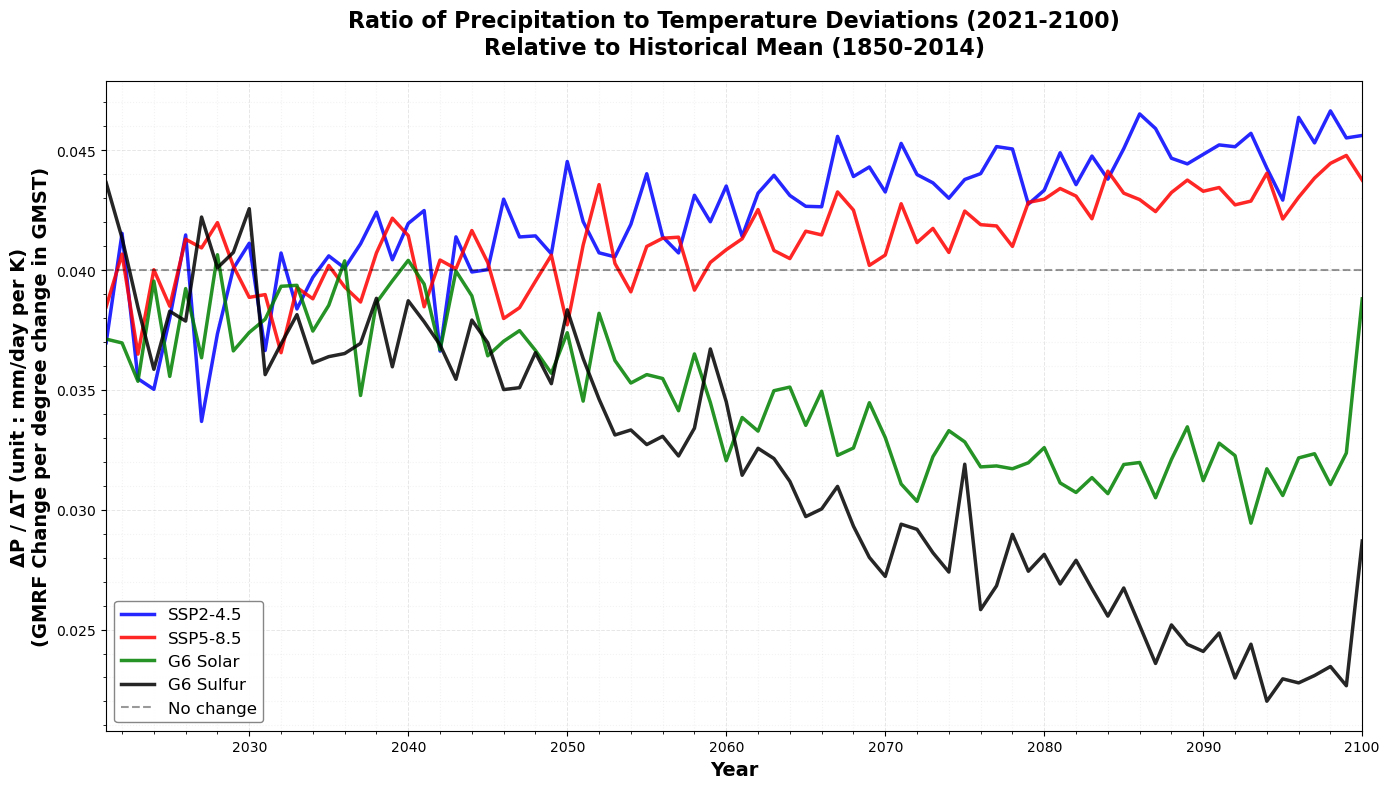


SUMMARY STATISTICS: ΔP/ΔT RATIOS (2021-2100)

SSP2-4.5:
  Mean:     0.0424
  Median:   0.0429
  Std:      0.0028
  Min:      0.0337 (year 2027)
  Max:      0.0466 (year 2098)

SSP5-8.5:
  Mean:     0.0412
  Median:   0.0413
  Std:      0.0019
  Min:      0.0365 (year 2023)
  Max:      0.0448 (year 2099)

G6 Solar:
  Mean:     0.0348
  Median:   0.0347
  Std:      0.0030
  Min:      0.0294 (year 2093)
  Max:      0.0406 (year 2028)

G6 Sulfur:
  Mean:     0.0320
  Median:   0.0324
  Std:      0.0057
  Min:      0.0220 (year 2094)
  Max:      0.0437 (year 2021)



In [20]:
"""
Climate Analysis: Rainfall/Temperature Ratio Analysis
Computes deviations from historical baseline and plots ratios for future scenarios
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: Compute Historical Means and Deviations
# ============================================================================

# Historical period: 1850-2014 (indices 0-164 in a 251-year array)
hist_start = 0
hist_end = 164

# Future analysis period: 2021-2100 (indices 171-250)
future_start = 171
future_end = 250

# Compute historical means
T_hist_mean = np.mean(T_ens['HIST'][hist_start:hist_end+1])
P_hist_mean = np.mean(P_ens['HIST'][hist_start:hist_end+1])

print("="*70)
print("HISTORICAL BASELINE (1850-2014)")
print("="*70)
print(f"Temperature mean: {T_hist_mean:.6f}")
print(f"Precipitation mean: {P_hist_mean:.6f}")
print()

# ============================================================================
# STEP 2: Compute Deviations for Each Experiment
# ============================================================================

experiments = ['SSP245', 'SSP585', 'G6solar', 'G6sulfur']
years_future = np.arange(2021, 2101)

# Store deviations and ratios
T_dev = {}
P_dev = {}
ratios = {}

print("="*70)
print("DEVIATIONS FROM HISTORICAL BASELINE (2021-2100)")
print("="*70)

for exp in experiments:
    # Extract future period
    T_future = T_ens[exp][future_start:future_end+1]
    P_future = P_ens[exp][future_start:future_end+1]
    
    # Compute deviations
    T_dev[exp] = T_future - T_hist_mean
    P_dev[exp] = P_future - P_hist_mean
    
    # Compute ratio: ΔP / ΔT
    ratios[exp] = P_dev[exp] / T_dev[exp]
    
    print(f"\n{exp}:")
    print(f"  Temperature deviation range: [{T_dev[exp].min():.4f}, {T_dev[exp].max():.4f}]")
    print(f"  Precipitation deviation range: [{P_dev[exp].min():.4f}, {P_dev[exp].max():.4f}]")
    print(f"  Mean ΔP/ΔT ratio: {np.mean(ratios[exp]):.4f}")
    print(f"  Median ΔP/ΔT ratio: {np.median(ratios[exp]):.4f}")

print("\n")

# ============================================================================
# STEP 3: Plot Rainfall/Temperature Ratios
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Color scheme
# colors = {
#     'SSP245': '#3288bd',  # Blue
#     'SSP585': '#d53e4f',  # Red
#     'G6solar': '#fee08b', # Yellow
#     'G6sulfur': '#66c2a5' # Teal
# }
colors = {
    'SSP245': 'blue',  # Blue
    'SSP585': 'red',  # Red
    'G6solar': 'green', # Yellow
    'G6sulfur': 'black' # Teal
}

labels = {
    'SSP245': 'SSP2-4.5',
    'SSP585': 'SSP5-8.5',
    'G6solar': 'G6 Solar',
    'G6sulfur': 'G6 Sulfur'
}

# Plot each scenario
for exp in experiments:
    ax.plot(years_future, ratios[exp], 
            color=colors[exp], 
            label=labels[exp],
            linewidth=2.5,
            alpha=0.85)

# Add reference line at y=0
ax.axhline(y=0.04, color='black', linestyle='--', linewidth=1.5, alpha=0.4, 
           label='No change')

# Formatting
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('ΔP / ΔT (unit : mm/day per K)\n(GMRF Change per degree change in GMST)', 
              fontsize=14, fontweight='bold')
ax.set_title('Ratio of Precipitation to Temperature Deviations (2021-2100)\n' + 
             'Relative to Historical Mean (1850-2014)',
             fontsize=16, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=12, framealpha=0.95, edgecolor='gray')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_xlim(2021, 2100)

# Add minor gridlines
ax.grid(True, which='minor', alpha=0.15, linestyle=':')
ax.minorticks_on()

plt.tight_layout()

# Save figure
output_path = './Figure_rainfall_temperature_ratio.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f"✓ Plot saved to: {output_path}")

plt.show()

# ============================================================================
# STEP 4: Summary Statistics
# ============================================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS: ΔP/ΔT RATIOS (2021-2100)")
print("="*70)

for exp in experiments:
    print(f"\n{labels[exp]}:")
    print(f"  Mean:   {np.mean(ratios[exp]):8.4f}")
    print(f"  Median: {np.median(ratios[exp]):8.4f}")
    print(f"  Std:    {np.std(ratios[exp]):8.4f}")
    print(f"  Min:    {np.min(ratios[exp]):8.4f} (year {years_future[np.argmin(ratios[exp])]})")
    print(f"  Max:    {np.max(ratios[exp]):8.4f} (year {years_future[np.argmax(ratios[exp])]})")

print("\n" + "="*70)